In [1]:
import numpy as np
from matplotlib import pyplot as plt
from lakeshore import Model240, Model240InputParameter, Model240CurveHeader
import time
import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
import pandas as pd
import datetime
import os
from scipy.optimize import curve_fit

In [2]:
import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
import pandas as pd

big_plt_font()
rm = visa.ResourceManager()
## uncomment the following if full address not known
instruments = rm.list_resources() 
usb = list(filter(lambda x: 'USB' in x, instruments))
# SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')
SSA = rm.open_resource(usb[1])
print(SSA.query("*IDN?"))

Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10



In [3]:
freq_center = 222 # MHz
freq_span = 20 # MHz
RBW_AUTO = 0 #1-ON, 0-OFF
VBW_AUTO = 1 #1-ON, 0-OFF
SWT_AUTO = 1 #1-ON, 0-OFF
VBW_RBW_RAT = 10 
RBW = 10 #kHz
VBW = 100 #kHz
SWT = 1 #ms
N_AVG = 100

In [4]:
# Configure frequency
SSA.write("SENS:FREQ:CENT " + str(freq_center) + " MHz")
SSA.write("SENS:FREQ:SPAN " + str(freq_span) + " MHz")

# Configure bandwidths and sweep time
SSA.write("SENS:BWID:AUTO " + str(RBW_AUTO))
SSA.write("SENS:BWID:VID:AUTO " + str(VBW_AUTO))
SSA.write("SENS:SWE:TIME:AUTO " + str(SWT_AUTO))
SSA.write("SENS:BWID:VID " + str(VBW) + " kHz")
SSA.write("SENS:BWID " + str(RBW) + " kHz")
SSA.write("SENS:BWID:VID:RAT " + str(VBW_RBW_RAT))
SSA.write("SENS:SWE:TIME " + str(SWT) + " ms")

# Set sweep mode to FFT
SSA.write(":SWEep:MODE FFT")

# Set averaging ON and number of averages = 100
# SSA.write(":AVERage:TRACe1:COUNt 1")
SSA.write(f":AVERage:TRACe1:COUNt {N_AVG}")
SSA.write(f":TRACe1:MODE AVERage")
time.sleep(SWT*1e-3*N_AVG)

# Set power unit to dBm
SSA.write("UNIT:POW DBM")

14

In [5]:
SSA.write(":AVERage:TRAC1:CLEar")

22

In [6]:
int(SSA.query(":AVERage:TRACe1?"))

0

In [7]:
def SSA_scan(path):
    
    SSA.write(":AVERage:TRAC1:CLEar")
    while int(SSA.query(":AVERage:TRACe1?")) < N_AVG: 
        continue
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')])
    
    # Number of points in the trace
    num_points = len(data_arr_C)
    
    # Generate frequency axis in MHz
    freq_start = freq_center - freq_span / 2
    freq_stop  = freq_center + freq_span / 2
    freq_axis = np.linspace(freq_start, freq_stop, num_points)
    
    # --- Plot ---
    plt.figure(figsize=(8,6))
    # plot(freq_axis, data_arr_C, label="Avg = 1")
    # plot(freq_axis, data_arr_B, label="Average = 1")
    # plot(freq_axis, 10*np.log10(data_arr_C), label="PC Avg = 100")
    plot(freq_axis, data_arr_C, label="SA Avg = 100")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Power (dBm)")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    data = {'freq': freq_axis, 'pow':data_arr_C}
    df = pd.DataFrame(data)
    df.to_csv(path)

In [2]:
# Connect to the first available Model 240 over USB
my_model_240 = Model240()
# Define the channel configuration for a sensor with a negative temperature coefficient, autorange disabled
# current reversal disabled, the channel enabled, and set to the 100 kOhm range
rtd_config = Model240InputParameter(my_model_240.SensorTypes.DIODE, False, False, my_model_240.Units.SENSOR, True,
                                    my_model_240.InputRange.RANGE_DIODE)
# Apply the configuration to all channels
for channel in range(1, 3):
    my_model_240.set_input_parameter(channel, rtd_config)

In [11]:
ch1V = my_model_240.get_sensor_reading(1)
ch1K = my_model_240.get_kelvin_reading(1)
ch2V = my_model_240.get_sensor_reading(2)
ch2K = my_model_240.get_kelvin_reading(2)

In [12]:
ch2K, ch1K

(62.362, 71.456)


sweep 0/100: the time is 2025-12-14-15105 and the temperature is 10.792 K



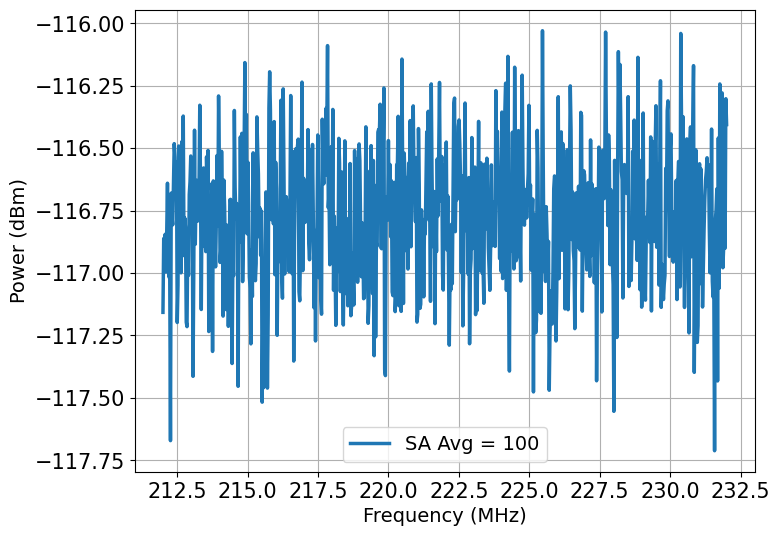

KeyboardInterrupt: 

In [11]:
folder_path = 'edes/edes/modules/spectrum_analyzer/cryo-data/12_11_25_cooldown'
os.makedirs(folder_path, exist_ok=True)

I = 100
for i in range(I):
    date_time = str(datetime.datetime.now()).replace(' ','-').replace(':','')[:16]

    #temperature measurement
    ch1V = my_model_240.get_sensor_reading(1)
    ch1K = my_model_240.get_kelvin_reading(1)
    ch2V = my_model_240.get_sensor_reading(2)
    ch2K = my_model_240.get_kelvin_reading(2)

    print('')
    print(f'sweep {i}/{I}: the time is {date_time} and the temperature is {ch1K} K')
    print('')

    filename = 'tank-circuit_' + 'T1_' + str(round(ch1K,3)) + '_T2_' + str(round(ch2K,3))+ '_' +date_time +'.csv'

    SSA_scan(filename)
    
    time.sleep(30*60*60) #every 30 minutes
   

In [ ]:
df = pd.read_csv('tank-circuit_T1_63.07_T2_52.252_2025-12-11-17091.csv', delimiter = ',')
plt.plot(df['freq'], df['pow'])

In [ ]:
df